<h1>   
 Convolution Neural Network for News Classification
</h1>
<h2>ΠΕΤΡΟΣ ΛΑΖΑΡΟΥ 02000</h2>
Σε αυτή την εργασία θα χρησιμοποιήσω ένα CNN με σκοπό τη ταξινόμηση ειδήσεων με βάση τη περιγραφή τους και το τίτλο τους.
<h2>
Σχετικά με το dataset:
</h2>
Το dataset περιέχει 210,000 headlines απο το HuffPost και σκοπός μας είναι να χτίσυομε ένα μοντέλο που με βάση το title και το short description να μπορέσουμε να κατηγοριοποίσουμε την είδηση σε μία απο τις 42 κατηγορίες ειδήσεων.
<h2>ΠΕΡΙΕΧΟΜΕΝΑ DATASET </h2>

    category: category in which the article was published.
    headline: the headline of the news article.
    authors: list of authors who contributed to the article.
    link: link to the original news article.
    short_description: Abstract of the news article.
    date: publication date of the article.
<h2>ΓΙΑΤΙ ΧΡΗΣΙΜΟΠΟΙΟΥΜΕ CNN?</h2>
Χρησιμοποίουμε CNN γιατί μας είναι χρήσιμο το μοντέλο των N-grams μιας και μιλάμε για μικρά κατα βάση κείμενα (όπως θα δούμε και παρακάτω), επίσης καταβάση μας ενδιαφέρει να κάνουμε capture key-phrases όπως πχ stock market για τη ταξινόμηση , ενώ δεν μας ενδιαφέρουν ιδιαίτερα οι μακρινές σχέσεις για να χρησιμοποιούσαμε RNN. Πέρα απο αυτό ένα RNN θα είχε πολλούς περισσότερες παραμέτρους χώρις κάποιο ιδιαίτερο benefit.

Για αρχή απενεργοποιούμε τα warnings που μπορούν να εμφανιστούν και επιτρέπουμε μόνο το errors με σκοπό να μην είναι πολύ cluttered τα outputs 

In [39]:
import os 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

Ύστερα ανοίγουμε το αρχείο μας και θα αξιοποιήσουμε τη βιβλιοθήκηκη "pandas" να φοτώσουμε και να επεξαργουστέμα αποδοτικά τα δεδομένα σε μία μορφή έξυπνου πινακα.Για αρχή βλέπουμε λίγο τα δεδομένα μας για να έχουμε ιδέα με τι δουλεύουμε.

In [40]:
import pandas as pd
json_path = 'News_Category_Dataset_v3.json'
df = pd.read_json(json_path, lines=True)
pd.set_option('display.max_colwidth', None)
print(df.head(3))
pd.reset_option('display.max_colwidth')

                                                                                                                                     link  \
0                                                      https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9   
1  https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25d3e4b0e247890329fe   
2                                     https://www.huffpost.com/entry/funniest-tweets-cats-dogs-september-17-23_n_632de332e4b0695c1d81dc02   

                                                                                    headline  \
0               Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters   
1  American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video   
2                      23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23)   

    category  \
0  U.S. NEWS   
1  U.S. NEWS   
2 

Εδώ τυπώνουμε το μέγεθος του dataset και βλέπουμε πως έχει στο σύνολο 209,527 entries και 6 κατηγορίες δεδομένων για το κάθε entry.

In [41]:
print(df.shape)

(209527, 6)


Επίσης τυπώνουμε μία επισκόπηση των δεδομένων και παρατηρούμε ότι δεν έχουμε null δεδομένα αρα δεν χρειάζεται να ασχοληθούμε με αυτα.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 11.2+ MB


Γενικά θα αξιοποίσουμε ένα συνδυασμό του headline και του short description ως τα δεδομένα input ,άρα φτιάχνουμε μια καινούρια στήλη που τα συνδυάζει , πέρα απο αυτό κάνουμε τα δεδομένα να μετατραπούν όλα σε πεζά γράμματα μιας και το case των γραμμάτων δεν συνεισφέρει στη πληροφορία. Παρακάτω επίσης έχουμε ένα preview για να δούμε τι έκανε η μετατροπή.

In [43]:
df['text'] = df['headline'] + " " + df['short_description']
df['text'] = df['text'].str.lower()
print(df[['headline', 'short_description', 'text']].head(3).to_string(index=False))


                                                                                 headline                                                                                                                                               short_description                                                                                                                                                                                                                                                      text
             Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters      Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.                   over 4 million americans roll up sleeves for omicron-targeted covid boosters health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the u.s. ordered for the fall.


Δουλεύοντας στην εργασία συνειδητοποίησα ότι το val_accuracy ήταν αρκετά χαμηλό της τάξης του 0.5 , διαβάζοντας στο discussion του dataset στο kaggle συνειδητοποίησα πώς ένα πρόβλημα που υπάρχει για την εκπαίδευση είναι πως υπάρχουν αρχικά λίγα δεδομένα για τον αριθμό κατηγοριών που έχουμε και επίσης υπάρχουν κατηγορίες που έχουν ελάχιστες καταχωρήσεις το οποίο τις έκανε αρκετά δύσκολο να προβλεθούν ορθά. Έτσι μείωσα τις κατηγορίες κάνωντας merge παρόμοιες κατηγορίες με βάση για αρχή αυτές που βγάζαν λογική να είναι παρόμοιες και ύστερα ρώτησα και το chat-gpt για το να μου δώσει τις πιο παρόμοιες κατηγορίες με βάση τα δικά του embeddings για περαιτέρω συναινώσεις. Παρακάτω βλέπουμε τα συνολικά ποσοστά της κάθε κατηγορίας.
https://www.kaggle.com/datasets/rmisra/news-category-dataset/discussion/114275

In [44]:
print(df['category'].value_counts(normalize=True).round(3))

category
POLITICS          0.170
WELLNESS          0.086
ENTERTAINMENT     0.083
TRAVEL            0.047
STYLE & BEAUTY    0.047
PARENTING         0.042
HEALTHY LIVING    0.032
QUEER VOICES      0.030
FOOD & DRINK      0.030
BUSINESS          0.029
COMEDY            0.026
SPORTS            0.024
BLACK VOICES      0.022
HOME & LIVING     0.021
PARENTS           0.019
THE WORLDPOST     0.017
WEDDINGS          0.017
WOMEN             0.017
CRIME             0.017
IMPACT            0.017
DIVORCE           0.016
WORLD NEWS        0.016
MEDIA             0.014
WEIRD NEWS        0.013
GREEN             0.013
WORLDPOST         0.012
RELIGION          0.012
STYLE             0.011
SCIENCE           0.011
TECH              0.010
TASTE             0.010
MONEY             0.008
ARTS              0.007
ENVIRONMENT       0.007
FIFTY             0.007
GOOD NEWS         0.007
U.S. NEWS         0.007
ARTS & CULTURE    0.006
COLLEGE           0.005
LATINO VOICES     0.005
CULTURE & ARTS    0.005
EDUCATI

Εδώ βλέπουμε και ένα visual representation της κάθε κατηγορίας παρατηρούμε ότι υπάρχουν κατηγορίες που έχουν dominance που μπορεί να οδηγήσει σε λάθος ταξινόμηση μεσα σε αυτές τις κατηγορίες , ενώ ταυτόχρονα έχουμε πολύ μικρές κατηγορίες επίσης όπου θα έχουμε ελάχιστα δεδομένα να δουλέψουμε.

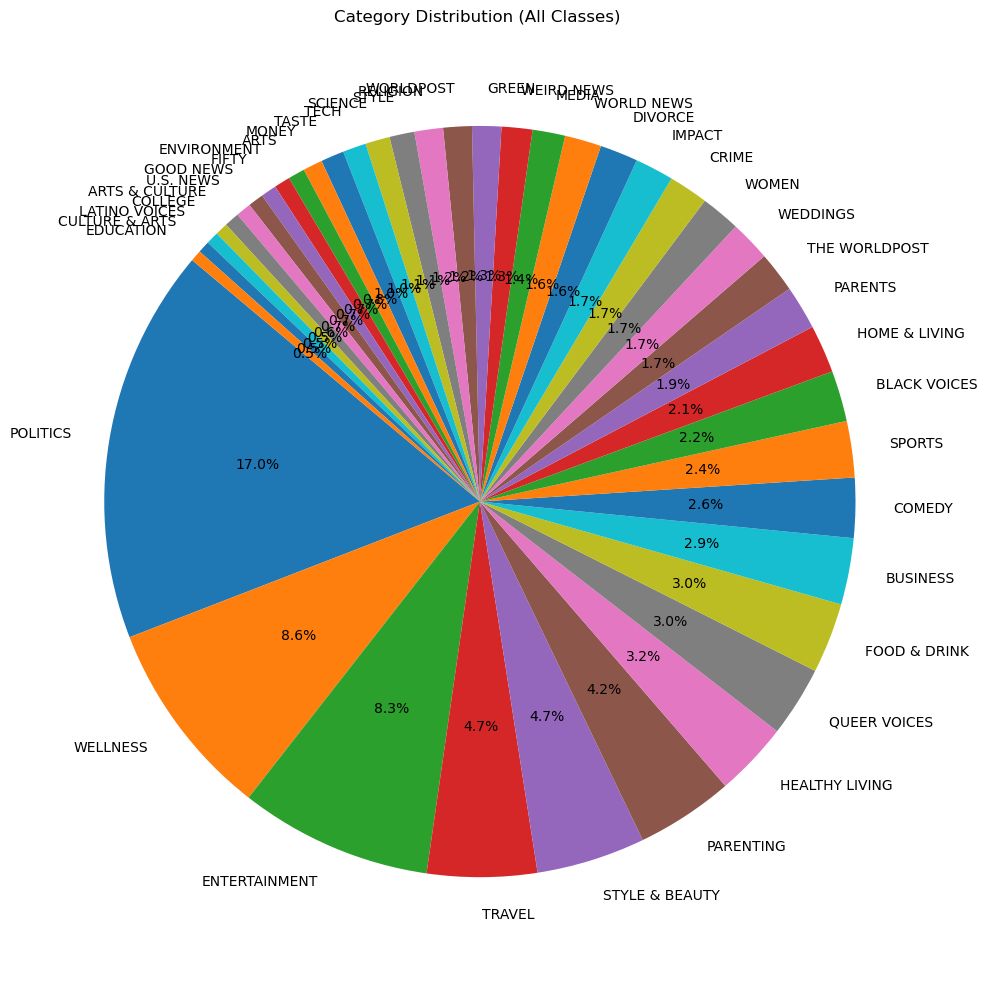

In [45]:
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts()
plt.figure(figsize=(10, 10))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Category Distribution (All Classes)")
plt.axis('equal')  # Equal aspect ratio makes the pie circular.
plt.tight_layout()
plt.show()

Εδώ ορίζουμε το merge map όπου έχουμε και μία κατηγορία OTHER για τις κατηγορίες που δεν ταιριάζουν κάπου αλλού αλλα έχουν πολύ μίκρα δείγματα.

In [46]:
merge_map = {
    "ARTS": "ENTERTAINMENT",
    "ARTS & CULTURE": "ENTERTAINMENT",
    "CULTURE & ARTS": "ENTERTAINMENT",

    "BLACK VOICES": "VOICES",
    "LATINO VOICES": "VOICES",
    "QUEER VOICES": "VOICES",
    "WOMEN": "VOICES",

    "WELLNESS": "WELLNESS_LIFESTYLE",
    "HEALTHY LIVING": "WELLNESS_LIFESTYLE",
    "STYLE & BEAUTY": "WELLNESS_LIFESTYLE",
    "GOOD NEWS": "WELLNESS_LIFESTYLE",

    "PARENTING": "HOME_PARENTING",
    "PARENTS": "HOME_PARENTING",
    "HOME & LIVING": "HOME_PARENTING",

    "WORLD NEWS": "WORLD_NEWS",
    "THE WORLDPOST": "WORLD_NEWS",
    "WORLDPOST": "WORLD_NEWS",
    "U.S. NEWS": "WORLD_NEWS",

    "TECH": "SCI_TECH",
    "SCIENCE": "SCI_TECH",
    "ENVIRONMENT": "SCI_TECH",
    "GREEN": "SCI_TECH",

    "STYLE": "WELLNESS_LIFESTYLE",
    "FIFTY":"WELLNESS_LIFESTYLE",

    "COMEDY": "ENTERTAINMENT",
    "SPORTS": "ENTERTAINMENT",
    "ARTS_CULTURE": "ENTERTAINMENT",

    "DIVORCE": "WEDDINGS",

    "COLLEGE": "EDUCATION",

    "TASTE": "FOOD & DRINK",
    "MONEY": "BUSINESS",
    "IMPACT": "OTHER",
    "WEIRD NEWS": "OTHER",
    "MEDIA": "OTHER"
}

df['category'] = df['category'].replace(merge_map)

Τώρα βλέπουμε την αναπαράσταση μετά τη συνένωση που είναι πολύ πιο balanced απο την αρχικές κατηγορίες το οποιό θα βοηθήσει σε καλύτερο accuracy στο μοντέλο.

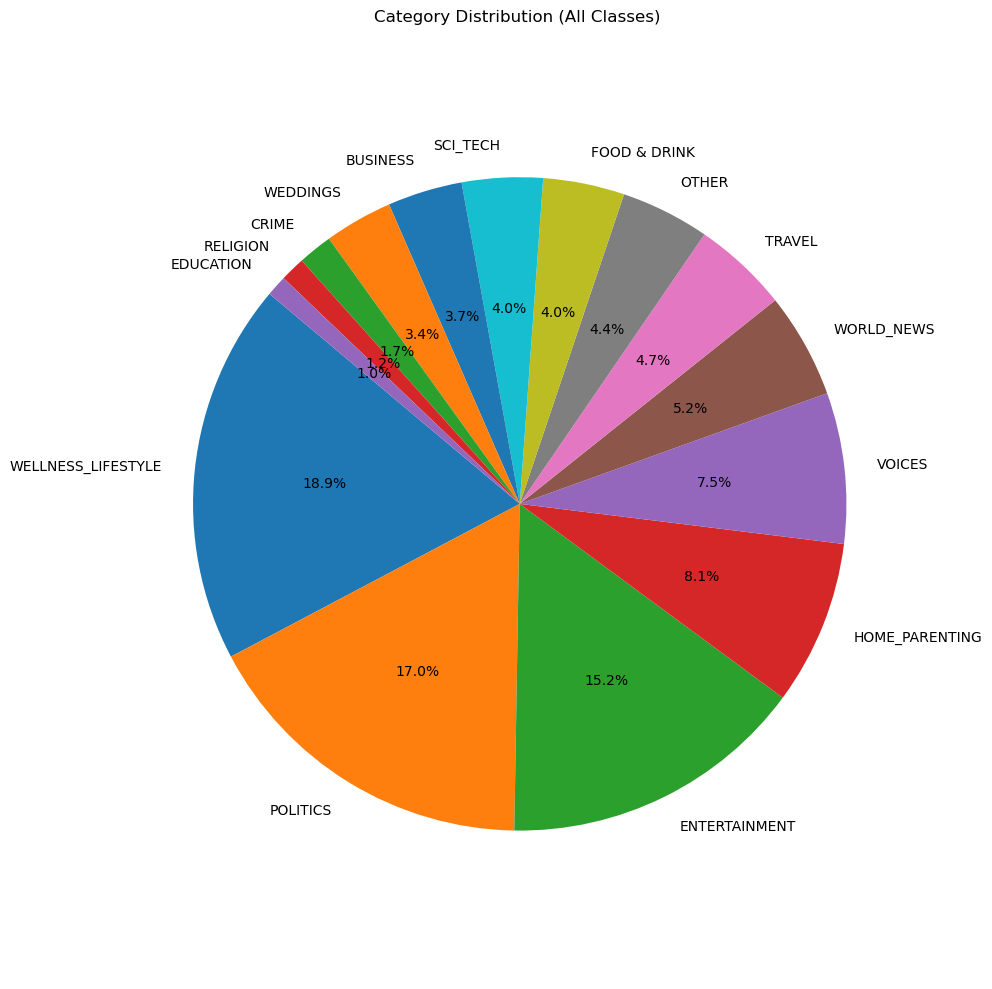

In [47]:
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts()
plt.figure(figsize=(10, 10))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Category Distribution (All Classes)")
plt.axis('equal')  # Equal aspect ratio makes the pie circular.
plt.tight_layout()
plt.show()

Αντίστοιχα βλέπουμε και τα δεδομένα αριθμητικά.

In [48]:
print(df['category'].value_counts(normalize=True).round(3))

category
WELLNESS_LIFESTYLE    0.189
POLITICS              0.170
ENTERTAINMENT         0.152
HOME_PARENTING        0.081
VOICES                0.075
WORLD_NEWS            0.052
TRAVEL                0.047
OTHER                 0.044
FOOD & DRINK          0.040
SCI_TECH              0.040
BUSINESS              0.037
WEDDINGS              0.034
CRIME                 0.017
RELIGION              0.012
EDUCATION             0.010
Name: proportion, dtype: float64


Εδώ βλέπουμε το πρώτο βήμα του καθαρισμού κειμένου μιας και αφαιρούμε οποιοδήποτε character δεν είναι αλφαρηθμητικό, πέρα απο αυτό κάνουμε τα πάντα πεζά ως δεικλίδα ασφαλείας. Επίσης χωρίζουμε το κείμενο φτιάχνοντας μια λίστα με τις λέξεις του έτσι ώστε να το αξιοποιήσουμε στη δημιουργία του λεξιλογίου και να μπορέσουμε να το αξιοποίησουμε σαν input μεσα στο CNN.

In [49]:
from collections import Counter
import re  #Η βιβλιοθήκη re μας αφήνει να αξιοποίησουμε regex patterns
def tokenize(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
    return text.split()

Ένα επίσης σημαντικό κομμάτι είναι η αφαίρεση των stopwords όπως "the,and,a" etc μιας και αυτές οι λέξεις δεν προσφέρουν κάποια ουσιαστική πληροφορία.

In [50]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
def remove_stopwords(text):
    tokens = tokenize(text)#Σπάσε το κείμενο σε μία λίστα
    filtered_tokens = [word for word in tokens if word not in stop_words] #Εφάρμοσε τη συνάρτηση tokenize
    return filtered_tokens
df['text_clean'] = df['text'].apply(remove_stopwords)#Φτιάξε καινούργια στήλη στο dataframe όπου θα έχει καθαρίσει το κείμενο

Εδώ βλέπουμε τη καθαρισμένη μορφή του κειμένου 

In [51]:
pd.set_option('display.max_colwidth', None)
print(df['text_clean'].head(2))
pd.reset_option('display.max_colwidth')

0               [4, million, americans, roll, sleeves, omicrontargeted, covid, boosters, health, experts, said, early, predict, demand, match, 171, million, doses, new, boosters, ordered, fall]
1    [american, airlines, flyer, charged, banned, life, punching, flight, attendant, video, subdued, passengers, crew, fled, aircraft, confrontation, according, attorneys, office, los, angeles]
Name: text_clean, dtype: object


Χωρίζουμε το dataframe σε δεδομένα εκπαίδευσης , επικύρωσης και test, τα δεδομένα εκπαίδευσης χρησιμοποιούνται για την εκπαίδευση του μοντέλου, τα επικύρωσης για ρύθμιση των υπερπαραμέτρων στην εκπαίδευση και για την αποφυγή overfitting, πέρα απο αυτό το test αξιοποιείται για την δοκιμή του μοντέλου σε δεδομένα που δεν έχουμε δεί προηγουμένωνς. Ο χωρισμός γίνεται σε 85% train + validation(απο όπου το 15% απο αυτά είναι στο validation test) 15%test.

In [52]:
from sklearn.model_selection import train_test_split
train_plus_temp, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df['category'], #Χρησιμοποιούμε το stratify με σκοπό να έχουμε παρόμοια αναλογία της κάθε κατηγορίας μέσα στους διαχωρισμούς
    random_state=98
)

train_df, val_df = train_test_split(
    train_plus_temp,
    test_size=0.15,
    stratify=train_plus_temp['category'],
    random_state=98
)
print("Train Set Size:" + str(train_df.shape[0]))
print("Validation Set Size:" + str(val_df.shape[0]))
print("Test Set Size:" + str(test_df.shape[0]))



Train Set Size:151382
Validation Set Size:26715
Test Set Size:31430


In [53]:
import itertools
all_train_tokens = list(itertools.chain.from_iterable(train_df['text_clean']))
print(len(all_train_tokens))
print(all_train_tokens[0:10])

2480876
['repair', 'broken', 'heart', 'sure', 'broken', 'heart', 'broken', 'heart', 'deep', 'swelling']


Παρακάτω φτιάχνουμε μία λίστα με όλες τις λέξεις στο σύνολο τους.

In [54]:
from collections import Counter
freq = Counter(all_train_tokens)
print(len(freq))

98165


Εδώ αξιοποιούμε τη παραπάνω συνάρτηση , και αφαιροόυμε όσες λέξεις υπάρχουν λιγότερες απο δύο φορές , οι λόγοι είναι οι εξής: 
- Μείωση των δεδομένων για την αύξηση της αποδοτικότητας
- Τα δεδομένα με λίγες εμφανίσεις δεν προσδίδουν ιδιαίτερη πληροφορία
- Αποφυγή overfitting 

In [55]:
min_freq = 2
common_words = {word for word, count in freq.items() if count >= min_freq} #Κράτησε μόνο τις λέξεις όπου εμφανίζονται πάνω απο min_freq, και επέστρεψε ένα set με τις λέξεις αυτές.
print(len(common_words))

53871


Εδώ δείχνουμε ότι αφαιρέσαμε 44294 λέξεις , ενώ κρατήσαμε 53871 , παρόλαυτα καλύπτουμε το 98% των συνολικών λέξεων , άρα η αφαίρεση των λέξεων δεν μας δημιουργεί πρόβλημα ως έλλειψη δεδομένων.

In [56]:

total_tokens = sum(freq.values())  
total_types  = len(freq)   
dropped_words = set(freq) - common_words
covered_count  = sum(freq[w] for w in common_words)
dropped_count = total_tokens - covered_count
coverage_pct  = covered_count / total_tokens * 100
print(f"Min freq = {min_freq}:")
print(f"  Number of unique kept types:   {len(common_words)}")
print(f"  Number of unique dropped types: {len(dropped_words)}")
print(f"  Total tokens covered:  {covered_count} of {total_tokens} ({coverage_pct:.2f}% coverage)\n")


Min freq = 2:
  Number of unique kept types:   53871
  Number of unique dropped types: 44294
  Total tokens covered:  2436582 of 2480876 (98.21% coverage)



Στο παρακάτω κομμάτι κάνουμε τη ξεκαθάριση , για κάθε λέξη μες στα σύνολα train_df,val_df,test_df ελέγχουμε αν οι λέξεις βρίσκονται στο common words και μόνο αυτές κρατάμε, πέρα απο αυτό κατασκευάζουμε το συνολικό λεξικό με τις λέξεις του common words και τα PAD και UNK.


In [57]:

train_df['tokens_filtered'] = train_df['text_clean'].apply(
    lambda toks: [w for w in toks if w in common_words] #Εδώ για κάθε λέξη μες στις λέξεις του text clean τρέχουμε μια λααμδα συνάρτηση για να δούμε αν ανήκει στο common words
)
val_df['tokens_filtered'] = val_df['text_clean'].apply(
    lambda toks: [w for w in toks if w in common_words]
)
test_df['tokens_filtered'] = test_df['text_clean'].apply(
    lambda toks: [w for w in toks if w in common_words]
)
vocab = {"<PAD>": 0, "<UNK>": 1} #το PAD χρησιμοποίεται για το αν το μήκος του κειμένου είναι μικρότερο απο το σταθερό μήκος της κάθε φράσης να το γεμίσουμε
                                 #ενώ το UNK για άγωνστες λέξεις
for idx, word in enumerate(common_words, start=2):
    vocab[word] = idx
vocab_size = len(vocab)
print("Total vocab size:", vocab_size)


Total vocab size: 53873


Στο παρακάτω κομμάτι χρησιμοποιούμε το Label Encoding για να αντιστοιχήσουμε τη κάθε κατηγορία σε ένα μοναδικό ακέραιο , για να αξιοποιηθεί μετά απο το μοντέλο μας.

In [58]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(train_df['category'])  # Τρέχουμε τη συνάρτηση μόνο για το train_df η οποία θα παράγει τους μοναδικούς ακεραίους
train_df['label'] = le.transform(train_df['category'])#Ενώ τώρα εφαρμόζουμε τη συνάρτηση , και έτσι αντισοτοιχούμε τους μοναδικούς ακεραιούς
val_df['label']   = le.transform(val_df['category'])
test_df['label']  = le.transform(test_df['category'])

Ορίζουμε κάποιο max_len διότι στο CNN θα χρειαστούμε είσοδος σταθερού μεγέθους, όσο μεγαλώνει το max_len τόσο λιγότερο αποδοτικό θα γίνει το μοντέλο ενώ όσο μικρότερο είναι τόσο λιγότερα δεδομένα θα έχουμε στην εκπαίδευση εδώ γενικά έχω διαλέξει ένα αρκετα μεγάλο max_len, μεγαλύτερο απο το μήκος του 99% των entries. Ο λόγος που διάλεξα τόσο μεγάλο ταβάνι είναι διότι υπήρχε πρόβλημα με το overfitting αρά μείωσα την αποδοτικότητα έτσι ώστε να κερδίσω ακρίβεια.

In [59]:
pd.set_option('display.max_colwidth', None)


pd.reset_option('display.max_colwidth')
print(len(train_df['tokens_filtered'].iloc[0]))
lengths = train_df['tokens_filtered'].apply(len)

avg_length = lengths.mean()

print("Average tokens_filtered length:", avg_length)
print("99th percentile of tokens_filtered length:", lengths.quantile(0.99))
print("Absolute max length", max(lengths))
max_len = 40

17
Average tokens_filtered length: 16.095586000977658
99th percentile of tokens_filtered length: 33.0
Absolute max length 118


Στο παρακάτω κομμάτι εχουμε 2 συναρτήσεις πρώτη πάει και αντιστοιχεί τη κάθε λέξη στο αντίστοιχο index, ενώ αν δεν υπάρχει η λέξη στο λεξιλόγιο ορίζεται ως άγνωηστη λέξη "UNK",έτσι έχουμε μια αριθμητική παράσταση του λεξιλογίου. Ενώ στη 2η συνάρτηση εφαρμόζουμε padding έτσι ώστε όλες οι λέξες να έχουν το ίδιο μήκος.

In [60]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
def tokens_to_indices(tokens, vocab, unk_token="<UNK>"):
    unk_idx = vocab[unk_token]
    return [vocab.get(w, unk_idx) for w in tokens]
def sequences_and_pad(df_split):
    sequences = df_split['tokens_filtered'].apply(
        lambda toks: tokens_to_indices(toks, vocab)
    ).tolist()
    return pad_sequences(
        sequences,
        maxlen=max_len,
        padding="post",         #Κάνε padding στο τέλος της λέξης
        truncating="post",      #Αν είναι μεγαλύτερο του μέγιστου μήκους κόψε τα τελευταιά tokens μέχρι να φτάσει το μέγιστο μήκος
        value=vocab["<PAD>"]
    )

Εδώ εφαρμόζουμε τις συναρτήσεις που ορίσαμε παραπάνω και έτσι πλέον έχουμε τα δεδομένα να είναι προετοιμασμένα για το νευρωνικό δίκτυο. Πέρα απο αυτό επίσης προετοιμάζομε και τα labels παίρνωντας τις τιμές τους σε μία λίστα για να μπορέσουμε να τις επεξεργαστουε μετά.

In [61]:
X_train = sequences_and_pad(train_df)
X_val   = sequences_and_pad(val_df)
X_test  = sequences_and_pad(test_df)
y_train_raw = train_df["label"].values
y_val_raw   = val_df["label"].values
y_test_raw  = test_df["label"].values



Μετατρέπουμε τα labels σε κατηγορικά δεδομένα , τύπου one-hot encoding μιας και αυτό χρείαζεται για τη σύγκριση με τη πραγματική τιμή με βάση τη CategoricalCrossentropy που αξιοποιεί softmax και label smoothing.

In [62]:
from tensorflow.keras.utils import to_categorical
num_classes = len(le.classes_) 
y_train = to_categorical(train_df["label"].values, num_classes=len(le.classes_))
y_val   = to_categorical(val_df  ["label"].values, num_classes=num_classes)
y_test  = to_categorical(test_df["label"].values,  num_classes=len(le.classes_))

Παρακάτω έχουμε το σχέδιο του μοντέλου μας. Το Input layer δέχεται έναν πίνακα σταθερού μήκους, ο οποίος έχει καθοριστεί από πριν, έτσι ώστε όλα τα κείμενα να έχουν τον ίδιο τύπο.<br>
Στη συνέχεια, το Embedding layer μετατρέπει κάθε λέξη (που έχει κωδικοποιηθεί ως αριθμός) σε ένα διάνυσμα 128 διαστάσεων. Αυτή η αναπαράσταση "μαθαίνεται" κατά τη διάρκεια της εκπαίδευσης και αντικατοπτρίζει τη σημασιολογική πληροφορία κάθε λέξης , με άλλα λόγια, λέξεις με παρόμοια νοήματα έχουν παρόμοια διανύσματα. <br>
Έπειτα, έχουμε τρεις παράλληλες στρώσεις Conv1D, μία για κάθε μέγεθος φίλτρου: 3, 4 και 5. Αυτές εντοπίζουν n-γραμ μοτίβα , δηλαδή σύντομες φράσεις από 3 έως 5 λέξεις. Κάθε φίλτρο αναζητά τα σημεία του κειμένου που ενεργοποιεί το γνωστό ή χρήσιμο μοτίβο για την ταξινόμηση. Από κάθε φίλτρο προκύπτει ένα feature map, το οποίο δείχνει πού εντοπίστηκε η ενεργοποίηση στο κείμενο.<br>
Στη συνέχεια, το GlobalMaxPooling layer κρατάει τη μέγιστη τιμή από κάθε feature map, επιλέγοντας ουσιαστικά το πιο έντονο "σήμα" από κάθε φίλτρο. Με αυτόν τον τρόπο, το μοντέλο εστιάζει μόνο στα σημαντικότερα σημεία του κειμένου, ανεξάρτητα από τη θέση τους μέσα στη φράση.
Μετά χρησιμοποιούμε το Concacenate ώστε να ενώσουμε τα αποτελέσματα απο το κάθε pooling , έτσι ώστε να μπορέσουμε να αποτήσουμε μία πιο συνολική εικόνας<br>
Μετά χρησιμοποιούμε ένα dropout layer όπου απενεργοποιούμε το 50% των νευρώνων διότι έχουμε μικρό dataset, και είναι αρκετά εύκολο να γίνει overfitiing <br>
Αξιοποιούμε ενα dense layer για να συνδυάσει τα χαρακτηριστικά απο τα προηγούμενα layers  , χρησιμοποιούμε Relu για να κάνουμε το σύστημα μη γραμμικό και να επιτρέψουμε μεγαλύτερη γενίκευση, πέρα απο αυτό χρησιμοποιούμε το regulizer μειώνει τη επιρρόη των κύριων βαρών , έτσι ώστε να μειώσουμε το overfitting ,έτσι ώστε για παράδειγμα επειδή έχουμε πολλές ειδήσεις με πολιτική στο δικό μας δείγμα δεν σημαίνει αναγκαστικά πως αυτο ισχύει αναγκαστικά και εκτός δείγματος<br>
Εδώ παλι χρησιμοποιούμε dropout πάλι για να αυξήσουμε τη γενίκευση<br>
Εδώ χρησιμοποιούμε softmax στο τελευταίο dense layer για να βγάλουμε τις τελικές πιθανότητες<br>
Ύστερα χτίζουμε το μοντελό<br>
Στο compilation phase έχουμε για αρχή το Loss function , όπου χρησιμοποιούμε το CategoricalCrossentropy, σκοπός είναι να βρει τις προβλεπόμενες πιθανότητες και να τις συγκρίνει με τις πραγματικές τιμές , επίσης χρησιμοποιειται label smoothing για να κάνει ένα "spread" τις πιθανότητες από τη μεγαλύτερη πιθανότητα στις μικρότερες<br>
Μετά χρησιμοποιύμε και το AdamW ως optimizer, όπου θα υλοποιήσει το gradientDescent, έχει learning rate 0.001 το οποίο σημαίνει ότι αυτό είναι το βήμα για το κάθε update στο gradient descent ,πέρα απο αυτο δεν χρησιμοποιούμε adam αλλά adamw για να βάλουμε weight decay ουσιαστικά σε κάθε iteration μείωνουμε τη τιμή του κάθε βάρος κατα 0.0001 με σκοπό να να αυξήσουμε τη γενίκευση του μοντέλου , να βασίζεται λιγότερο στα βάρη που έχουν δοθεί από την εκπαίδευση.

In [63]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Concatenate, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
import tensorflow as tf

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len)(input_layer)

conv3 = Conv1D(128, 3, activation='relu', padding='same')(embedding_layer)#3GRAM
conv4 = Conv1D(128, 4, activation='relu', padding='same')(embedding_layer)#4GRAM
conv5 = Conv1D(128, 5, activation='relu', padding='same')(embedding_layer)#5GRAM

pool3 = GlobalMaxPooling1D()(conv3)
pool4 = GlobalMaxPooling1D()(conv4)
pool5 = GlobalMaxPooling1D()(conv5)

merged = Concatenate()([pool3, pool4, pool5])
drop1 = Dropout(0.5)(merged)

dense = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(drop1)
drop2 = Dropout(0.3)(dense)

output_layer = Dense(len(le.classes_), activation='softmax')(drop2)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=AdamW(weight_decay=1e-4, learning_rate=1e-3),
    metrics=['accuracy']
)

model.summary()



Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 40)]                 0         []                            
                                                                                                  
 embedding_1 (Embedding)     (None, 40, 128)              6895744   ['input_2[0][0]']             
                                                                                                  
 conv1d_3 (Conv1D)           (None, 40, 128)              49280     ['embedding_1[0][0]']         
                                                                                                  
 conv1d_4 (Conv1D)           (None, 40, 128)              65664     ['embedding_1[0][0]']         
                                                                                            

Εδώ βάζουμε το μοντέλο να τρέξει, για αρχή χρησιμοποιούμε τα class weights, ο σκοπός είναι να έχουμε υψηλότερο loss στις τάξεις με μικρότερη συχνότητα, μιας και αυτές τείνουν να έχουν μικρότερη ακρίβεια.<br>
Παρακάτω χρησιμοποιούμε early stopping με σκοπό να σταματήσουμε το training όταν δούμε πως το validation accuracy δεν ανεβαίνει, διότι μετα απο αυτό το σημείο τείνουμε να μην έχουμε βελτίωση στο validation accuracy και να ανεβαίνει το overfitting.<br>
Ύστερα επιτέλους ξεκινάμε το μοντέλο, βάζουμε ως όριο τις 30 εποχές αν και κατα βάση θα σταματήσει αρκετά νωρίτερα λόγω του early stoppubg

In [64]:
import numpy as np
y_train_indices = np.argmax(y_train, axis=1)#Μας επιστρέφει τις κλάσεις που αντιστοιχεί το κάθε hot encoding
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weight_dict = dict(enumerate(class_weights))
early_stopping = EarlyStopping(
    monitor='val_loss',        #Παρακολούθα το val_loss
    patience=3,                #Σταμάτα αφου βρείς 3 περιπτώσεις χειρότερες 
    restore_best_weights=True  #Επέστρεψε τη περίπτωση με το μεγαλύτερο accuracy 
                               
)
history = model.fit(
    X_train, y_train,               #τα train_data
    validation_data=(X_val,y_val),   #τα validation data
    epochs=30,               #Μέγιστες εποχές 
    batch_size=128,           #Πόσα δεδομένα θα χρησιμοποιεί ανα itteration 
    verbose=2,                  #Τύπωσε μια γραμμή ανα εποχή
    class_weight=class_weight_dict, #Εφάρμοσε τη προσαρμογή βαρών που εξήγησα παραπάνω
    callbacks=[early_stopping]      #Ενεργοποιήσε το Early Stopping
)

Epoch 1/30
1183/1183 - 26s - loss: 1.9480 - accuracy: 0.4787 - val_loss: 1.5978 - val_accuracy: 0.6282 - 26s/epoch - 22ms/step
Epoch 2/30
1183/1183 - 11s - loss: 1.4090 - accuracy: 0.6727 - val_loss: 1.4878 - val_accuracy: 0.6632 - 11s/epoch - 9ms/step
Epoch 3/30
1183/1183 - 10s - loss: 1.1960 - accuracy: 0.7458 - val_loss: 1.5074 - val_accuracy: 0.6524 - 10s/epoch - 9ms/step
Epoch 4/30
1183/1183 - 10s - loss: 1.0612 - accuracy: 0.7977 - val_loss: 1.5193 - val_accuracy: 0.6518 - 10s/epoch - 8ms/step
Epoch 5/30
1183/1183 - 9s - loss: 0.9708 - accuracy: 0.8379 - val_loss: 1.5146 - val_accuracy: 0.6620 - 9s/epoch - 8ms/step


Παρουσίασε το validation και training accuracy ανα εποχή.Στα αποτελέσματα παρατηρούμε ότι το training accuracy ανεβαίνει συνεχώς , ενώ το val_acc ανεβαίνει μεχρι τη 3 εποχή και μετα ξεκινάει μια μικρή πτώση, η παραπάνω εκπαίδευση δεν θα μας βελτιώσει αναγκαστικα το val_acc ενώ θα ανεβαίνει το overfit.

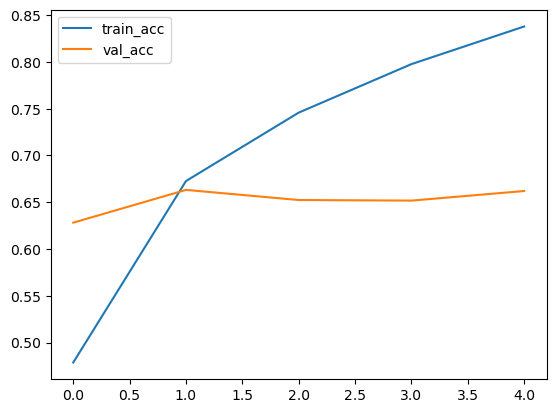

In [65]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

Κάνε prediction με βάση τα test data, και τύπωσε την ακρίβια ανά διαφορετική κλάσση, και ταξινόμησε τα ανά ποσοστό εμφάνισης.
- precision:απο όλες τις προβλέψεις ποιες είναι σωστές <br>
- recall: Από όλες τις περιπτώσεις ανα κλάσση πόσες βρέθηκαν σωστά
- f1: συνδυασμός precision και recall
- support: Σύνολο δειγμάτων
- proportion:Ποσοστό εμφάνισης στο σύνολο
Αυτό που παρατηρούμε είναι πως για τα δεδομένα που εμφανίζονται συχνά τύχει να έχουμε μεγαλύτερη ακρίβεια(να υπενθυμίσω πως τα proportions μεταξύ των test_set και train_set είναι παρόμοια), το οποίο είναι και λογικό μιας και έχει περισσότερα παραδείγματα για να μάθει, πέρα απο αυτό ύστερα απο τις βελτιστοποιήσεις βλέπουμε οτι η διαφορά δεν είναι τοσο μεγάλη, αν εξαιρέσουμε τις τάξεις EDUCATION που έχει ελάχιστα δείγματα όπως και η RELIGION και CRIME,πέρα απο αυτό το ίδιο βλέπουμε και στην OTHER μιας και αποτελείται απο διαφορετικές κλάσσεις αρα τα κείμενα σε αυτές είναι αρκετά διαφορετικά άρα είναι δύσκλο να τα εκπαιδεύσουμε. Αντίστοιχα κάτι αλλο που παρατηρώ είναι πως φένεται η διαφορά στο ENTERTAINMENT και το POLITICS είναι αρκετά μεγάλη στο accuracy , κάτι το οποίο θα μπορούσε να έχει συνεισφέρει εδώ είναι πως αντίστοιχα η ENTERTAINMENT αποτελείται απο υποκλάσσεις , το οποίο σημαίνει πάλι ότι το λεξιλόγιο στο ENTERTAINMENT τείνει να μην είναι τοσο κοινό αρα κάνει πιο δύσκολη την εκπαίδευση.

In [66]:
import numpy as np
from sklearn.metrics import classification_report
import pandas as pd

probs = model.predict(X_test)
y_pred = np.argmax(probs, axis=1)
y_true = np.argmax(y_test, axis=1)

report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

unique, counts = np.unique(y_true, return_counts=True)
class_counts = dict(zip(unique, counts))
total = len(y_true)

proportions = [class_counts.get(i, 0) / total for i in range(len(le.classes_))]

report_df = report_df.loc[le.classes_]
report_df['proportion'] = proportions
report_df = report_df.sort_values(by='proportion', ascending=False)
import pandas as pd
pd.set_option('display.max_columns', None)
print(report_df)


983/983 [==============================] - 1s 1ms/step
                    precision    recall  f1-score  support  proportion
WELLNESS_LIFESTYLE   0.817712  0.666892  0.734641   5926.0    0.188546
POLITICS             0.856064  0.658116  0.744152   5341.0    0.169933
ENTERTAINMENT        0.735187  0.677162  0.704983   4764.0    0.151575
HOME_PARENTING       0.708251  0.700781  0.704496   2560.0    0.081451
VOICES               0.645889  0.512580  0.571564   2345.0    0.074610
WORLD_NEWS           0.604514  0.686813  0.643041   1638.0    0.052116
TRAVEL               0.679812  0.777778  0.725503   1485.0    0.047248
OTHER                0.297773  0.416365  0.347222   1381.0    0.043939
FOOD & DRINK         0.646746  0.864032  0.739763   1265.0    0.040248
SCI_TECH             0.498300  0.583599  0.537587   1256.0    0.039962
BUSINESS             0.505109  0.595525  0.546603   1162.0    0.036971
WEDDINGS             0.734968  0.874765  0.798796   1062.0    0.033789
CRIME                0

Επέστρεψε το accuracy και το cross_entroypy_loss στα test data του συνολικού μοντέλου.<br>
Γενικα με CNN μοντελα φένεται το accuracy που πετυχένεται σε αυτο το dataset είναι γύρω στο 70% και μπορεί να φτάσει το 75-80% με τέλειο optimization, αρα το 65% είναι ένα σχετικά ικανοποιητικό αποτέλεσμα.<br>Το cross entropy loss μας δείχνει το κατα πόσο αποκλείουν οι προβλέψεις απο τα πραγματικά δεδομένα (έχει αυξηθεί και λόγω του label smoothing),η συγκεκριμένη τιμή μας δείνχει ότι όταν μας βρίσκει μία τιμή δεν το εκφράζει με πολύ μεγάλο confidence , αναφερόμαστε στο πίνακα παρακάτω.
| Model Behavior                                   | Accuracy Range | Expected Cross-Entropy Loss (w/ smoothing) |<br>
| ------------------------------------------------ | -------------- | ------------------------------------------ |<br>
| Totally random (uniform softmax)                 | \~6.7%         | 2.60 – 2.65                                |<br>
| Highly confident on wrong class                  | 10–40%         | 2.30 – 2.60                                |<br>
| Low confidence, spread-out predictions           | 40–55%         | 2.00 – 2.30                                |<br>
| Emerging correct dominance (top-1 \~0.3–0.5)     | 55–60%         | 1.80 – 2.00                                |<br>
| Moderate classifier (softmax peak \~0.5–0.7)     | 60–70%         | 1.50 – 1.80                                |<br>
| High confidence correct prediction (0.7–0.9)     | 70–80%         | 1.00 – 1.50                                |<br>
| Very strong classifier (softmax > 0.9)           | 80–90%         | 0.50 – 1.00                                |<br>
| Perfect softmax match to smoothed label          | 95–100%        | 0.25 – 0.50                                |<br>
| Impossible ideal (confidence=1 on correct class) | =100%          | ≈ 0.25                                     |<br>
<br>
(Πηγή gpto4 Cross Entropy Classifier με 15 κλάσσεις και label smoothing)
Άρα με βάση αυτα τα αποτελέσματα(accuracy =66% , loss = 1.49) είμαι στο moderate confidence.

In [67]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}, Test loss: {test_loss}")

983/983 - 2s - loss: 1.4877 - accuracy: 0.6638 - 2s/epoch - 2ms/step
Test accuracy: 0.6637607216835022, Test loss: 1.4877225160598755


Απο κάτω τρέχουμε ενα prediction στα test δεδομένα, αυτό που βλέπουμε για αρχή είναι πως αυτό που λαμβάνουμαι είναι ένας πίνακας, με 31,430 entries όσα δηλαδή και τα test δεδομένα μας, και η δεύτερη δίασταση έχει μήκος 15 όσο δηλαδή είναι και οι κλάσσεις μας. Παίρνουμε για το κάθε entry ένα πίνακα πιθανοτήτων που μας λέει ποια είναι η πιθανότητα με βάση το μοντέλο να ανήκει σε κάθε κατηγορία.Απο κάτω βλέπουμε τη πραγματική τιμή σε one hot encoding.Στο συγκεκριμένο παράδειγμα βλέπουμε ότι έχει γίνει λαθος πρόβλεψη , παρόλα αυτα κάτι αξιοσημείωτο είναι πως η πραγματική τιμή έχει τη 2η μεγάλυτερη πιθανότητα μεσα στις προβλεπόμενες τιμές.

In [68]:

probs_val = model.predict(X_test)
print(probs_val.shape)
y_pred_val = np.argmax(probs_val,axis=1)#Παίρνουμε το index της μέγιστης πιθανότητας απο τα αποτελέσματα της softmax
y_true_val = np.argmax(y_test,axis=1)#Παίρνουμε το μέγιστο από το one hot encoding , της πραγματικής κατηγορίας
np.set_printoptions(suppress=True)
pd.set_option('display.max_columns', None)
print(f"Πιθανότητες μοντέλου: {probs_val[0]}")
print(f"Αποτέλεσμα μοντέλου: {y_pred_val[0]}")
print(f"One hot encoding πραγματικής τιμής:{y_test[0]}")
print(f"Πραγματική τιμη:{y_true_val[0]}")

983/983 [==============================] - 1s 1ms/step
(31430, 15)
Πιθανότητες μοντέλου: [0.00149682 0.00243811 0.00373799 0.07297071 0.00020861 0.00181864
 0.01009927 0.00370614 0.00966031 0.00120139 0.00078484 0.8693452
 0.00491248 0.01353916 0.00408042]
Αποτέλεσμα μοντέλου: 11
One hot encoding πραγματικής τιμής:[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Πραγματική τιμη:3


Τώρα βλέπουμε και ένα κανονικοποιήμενο consfusion matrix, κάτι σημαντικό που μπορούμε να αποκομήσσουμε είναι πως η κύρια διαγώνιος έχει τις υψηλότερες πιθανότητες.

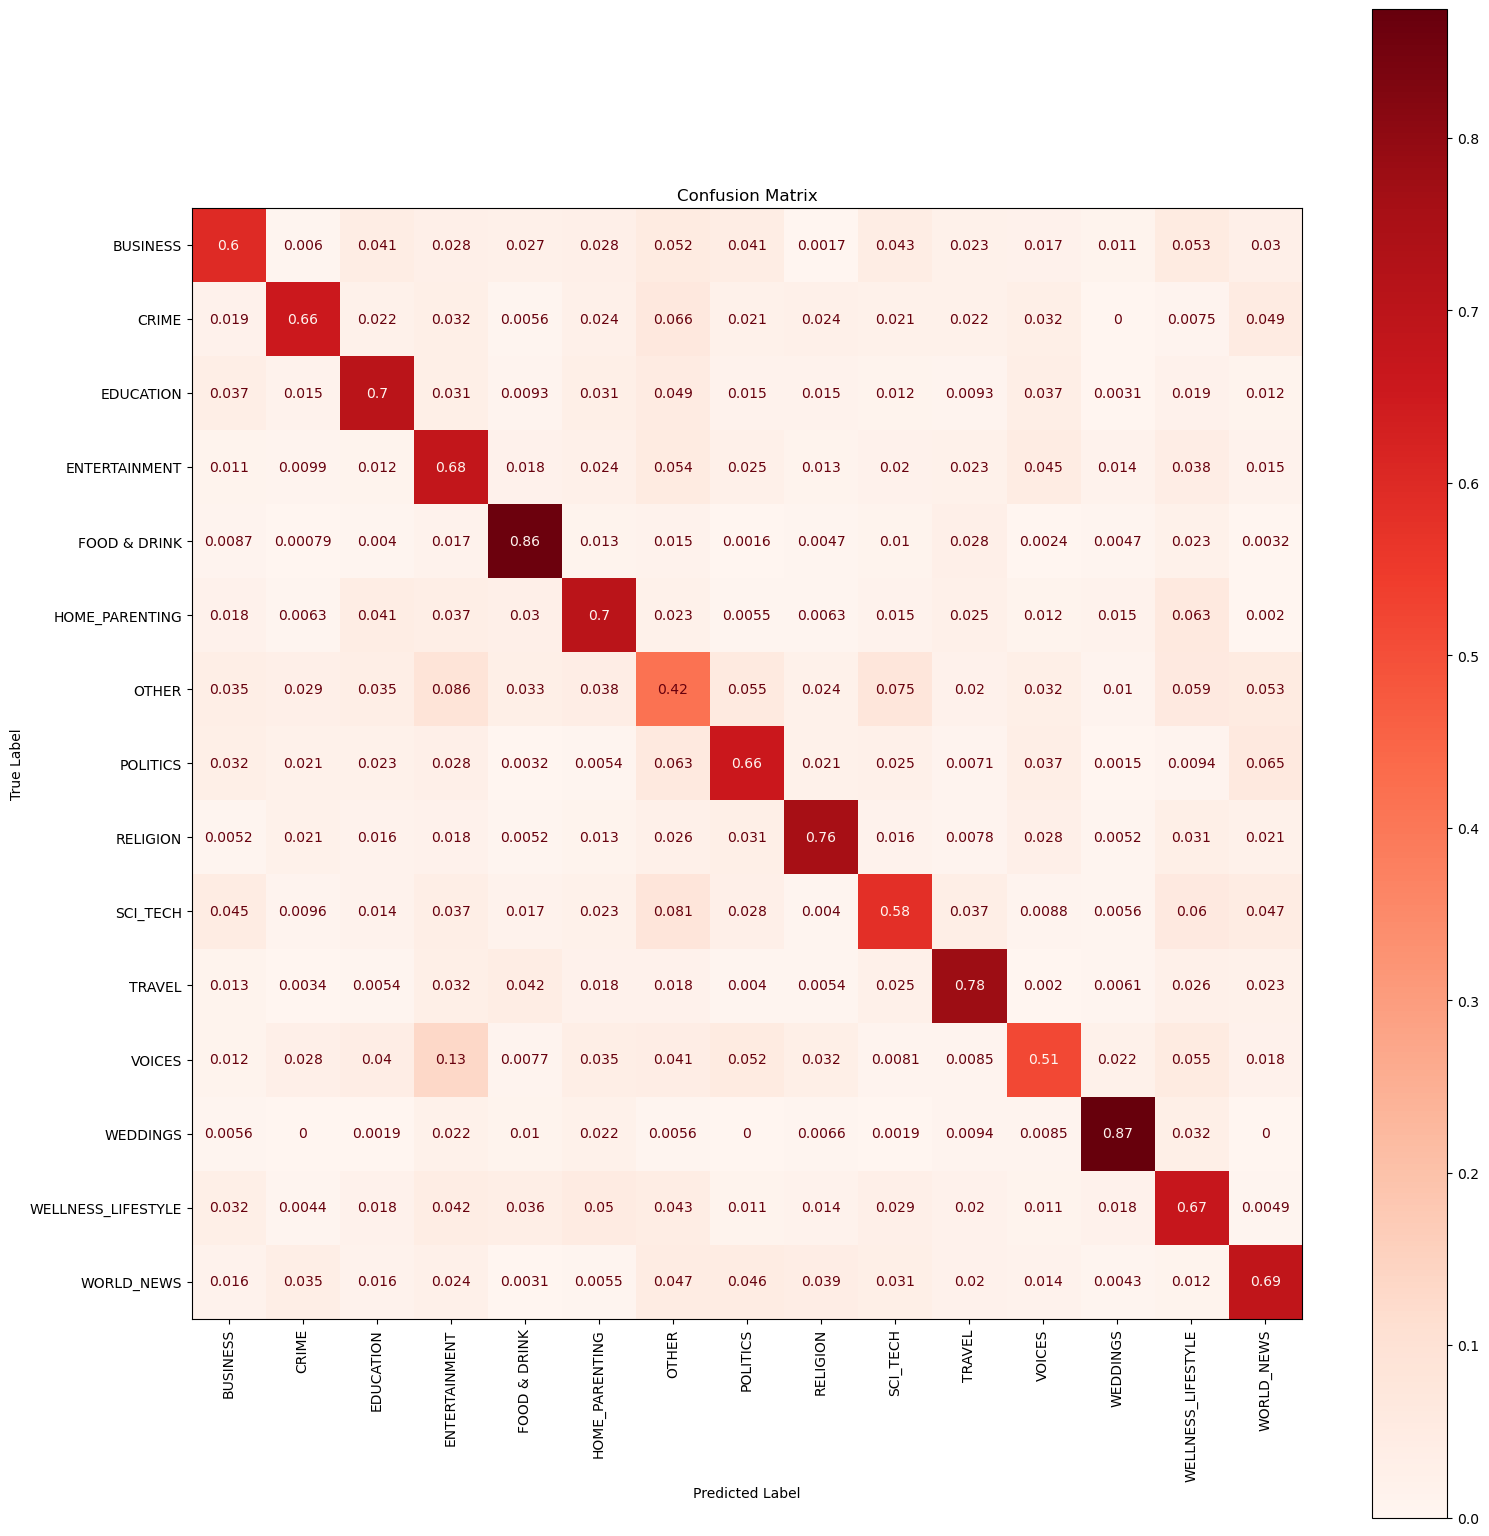

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true_val, y_pred_val,normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(cmap=plt.cm.Reds, ax=ax, colorbar=True)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

Εδώ χρησιμοποιούμε μια συνάρτηση για τη πρόβλεψη κατηγορίας , για custom δεδομένα, όπου έχουμε σαν είσοδο το title και το short description. Μόλις εισάγουμε τα δεδομένα τα κανονικοποιούμε (αφαιρούμε stop words, αφαιρούμε τις λέξεις που δεν βρίσκονται στα common words,κάνουμε PADDING και βάζουμε τα UNK στις λέξεις που δεν βρίσκονται στο λεξιλόγιο), ύστερα αξιοπιούμε το μοντέλο για να κάνουμε τη πρόβλεψη

In [70]:
def predict_category(title,short_description):
    text = title.join(short_description)
    cleaned_tokens = remove_stopwords(text)
    filtered_tokens = [w for w in cleaned_tokens if w in common_words]

    import pandas as pd
    temp_df = pd.DataFrame({'tokens_filtered': [filtered_tokens]})
    padded_sequence = sequences_and_pad(temp_df)

    probs = model.predict(padded_sequence, verbose=0)
    predicted_index = probs.argmax()#Πέρνουμε τη κατηγορία με τη μεγαλύτερη πιθανότητα
    predicted_label = le.inverse_transform([predicted_index])[0]#Μετατρέπουμε το encoding σε κείμενο 

    top3_indices = probs[0].argsort()[-3:][::-1]#Μας επιστρέφει τα indexes των πιθανοτήτων σε αύξουσα πιθανότητα , και πέρνουμε τις 3 τρελευταιές
    top3_labels = le.inverse_transform(top3_indices)
    top3_probs = probs[0][top3_indices]

    return {
        "predicted_label": predicted_label,
        "top_3_predictions": list(zip(top3_labels, top3_probs))
    }


Εδώ κάνουμε μια πρόβλεψη για ένα δικό μας άρθρο και βλέπουμε ότι το προβλέπει σωστά, με τεράστιο confidence , πάμε να κάνουμε κάποιες ακόμα δοκιμές να βγάλουμε κάποια συμπεράσματα.

In [71]:
result = predict_category("NASA discovery","NASA discovers a new exoplanet with potential life")
print("Predicted:", result["predicted_label"])
for label, prob in result["top_3_predictions"]:
    print(f"{label}: {prob:.2f}")

Predicted: SCI_TECH
SCI_TECH: 0.97
WORLD_NEWS: 0.01
OTHER: 0.01


Με το που βάλαμε το Trump αντί για NASA ξαφνικά μας δείνχει POLITICS, άρα αντίστοιχα και ο trump είναι defining για το POLITICS , εφόσον παρόλο που έχουμε τη NASA ακόμα στο δείγμα δεν δείχνεται καν στα 3 πρώτα δείγματα φένεται ότι η λέξη Trump έχει πολύ πιο δυνατό "confidence".

In [72]:
result = predict_category("Trump discovery","NASA discovers a new exoplanet with potential life")
print("Predicted:", result["predicted_label"])
for label, prob in result["top_3_predictions"]:
    print(f"{label}: {prob:.2f}")

Predicted: POLITICS
POLITICS: 0.46
OTHER: 0.20
ENTERTAINMENT: 0.09


Παρόλα αυτά αν αφαιρέσουμε το NASA τελείως ανεβαίνει αρκετά το CONFIDENCE στα POLITICS

In [73]:
result = predict_category("Trump discovery"," discovers a new exoplanet with potential life")
print("Predicted:", result["predicted_label"])
for label, prob in result["top_3_predictions"]:
    print(f"{label}: {prob:.2f}")

Predicted: POLITICS
POLITICS: 0.50
OTHER: 0.19
ENTERTAINMENT: 0.08


Εδώ βλέπουμε ότι σίγουρα η "NASA", πέζει κάποιο ρόλο στο να καθορίζει το SCI-TECH άλλα όχι τόσο τεράστιο

In [74]:
prob_with_nasa = predict_category("NASA headline", "NASA announces a new mission to Mars")


prob_without_nasa = predict_category("Space headline", "Agency announces a new mission to Mars")

print(f"SCI_TECH prob with 'NASA': {prob_with_nasa:}")
print(f"SCI_TECH prob without 'NASA': {prob_without_nasa:}")


SCI_TECH prob with 'NASA': {'predicted_label': 'SCI_TECH', 'top_3_predictions': [('SCI_TECH', 0.9432311), ('POLITICS', 0.019076128), ('OTHER', 0.012293661)]}
SCI_TECH prob without 'NASA': {'predicted_label': 'SCI_TECH', 'top_3_predictions': [('SCI_TECH', 0.65174174), ('OTHER', 0.082744375), ('POLITICS', 0.04890067)]}


Παρακάτω μετράμε τις συνολικές εμφανίσεις των λέξεων ανα κατηγορία για να πάρουμε μια ένδειξη για το ποιες ρόλες πέζουν μεγαλύτερο ρόλο , παρατηρούμε ότι στη κατηγορία POLITICS η λέξη Trump εμφανίζεται τις περισσότερες φορές άρα βγάζει νόημα γιατι να πέζει μεγάλο ρόλο στο καθορισμό των POLITICS ενώ η NASA δεν είναι συχνά εμφανιζόμενη στη SCI TECH.

In [75]:
from collections import Counter
import pandas as pd

def get_top_n_words_per_category(df, column='tokens_filtered', label_col='category',n=1):
    category_top_words = {}

    for category in df[label_col].unique():
        subset = df[df[label_col] == category]#Διάλεξε τις κατηγορίες όπου η κατηγορία είναι αυτη που περνάμε απο το iterator
        tokens = list(itertools.chain.from_iterable(subset[column]))#επέστρεψε για κάθε κατηγορία τις συνολικές λέξεις 
        word_freq = Counter(tokens)#μέτρα τις εμφανίσεις της κάθε λέξης
        top_words = word_freq.most_common(n)#διάλεξε τις n πιο συχνές
        category_top_words[category] = top_words# επέστρεψε την τούπλα των top λέξεων

    result_df = pd.DataFrame.from_dict(category_top_words, orient='index', columns=[f"word_{i+1}" for i in range(n)])#Χρησιμοποίησε τα κλειδιά ώς γραμμές και ώς στήλες το word_1,word_2 etc
                                                                                                                     #Είναι μία ανααράσταση του λεξικού
    return result_df

top_words_df = get_top_n_words_per_category(train_df, n=3)

print(top_words_df)


                             word_1           word_2            word_3
WELLNESS_LIFESTYLE   (photos, 3488)      (new, 2855)      (life, 2852)
FOOD & DRINK            (food, 907)   (recipes, 891)       (make, 783)
ENTERTAINMENT           (new, 2350)    (trump, 1377)      (just, 1309)
WORLD_NEWS            (people, 665)      (said, 643)        (new, 636)
CRIME                 (police, 631)       (man, 421)   (shooting, 288)
HOME_PARENTING         (kids, 2224)     (home, 1488)   (parents, 1420)
POLITICS              (trump, 7770)   (donald, 3301)    (trumps, 2539)
WEDDINGS            (wedding, 2127)  (divorce, 1785)   (marriage, 917)
BUSINESS                 (new, 633)  (business, 585)     (people, 422)
OTHER                    (new, 610)      (news, 587)     (people, 533)
VOICES                  (gay, 1459)    (black, 1290)     (women, 1260)
SCI_TECH                 (new, 763)   (climate, 710)     (change, 455)
TRAVEL               (travel, 1278)   (photos, 1268)        (new, 907)
EDUCAT

Σύντομη βιβλιογραφία
https://www.kaggle.com/datasets/rmisra/news-category-dataset/discussion?sort=hotness<br>
Deep Learning with Python SECOND EDITION FRANÇOIS CHOLLET<br>
https://www.geeksforgeeks.org/<br>
RNN_IMDB_Document_Classification-2025.ipynb<br>
https://chatgpt.com/<br>
https://www.youtube.com/watch?v=8NbXFoVk1mo<br>

In [76]:

submission_df = pd.DataFrame({
    'title': test_df['headline'].values,
    'short_description': test_df['short_description'].values,
    'true_label': le.inverse_transform(y_true_val),
    'predicted_label': le.inverse_transform(y_pred_val)
})

submission_df.to_csv("predicted_labels.csv", index=False)
